# Import Data & Info Data

In [ ]:
!git --version

import getpass

git version 2.34.1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = 'https://raw.githubusercontent.com/mfarhanshiddiq/Data-AssignmentDbb/main/AssignmentDay10.xlsx'

df = pd.read_excel(url)

print("Data berhasil dimuat!")
df.head(30)

Data berhasil dimuat!


,Nama,Usia,Total_Belanja,Domisili
0,Ayu,29,25788,Jakarta
1,Bima,24,21836,Jakarta
2,Citra,30,27395,Jakarta
3,Dion,28,25056,Jakarta
4,Eka,27,25448,Jakarta
5,Febri,22,19552,Jakarta
6,Gita,32,30292,Bandung
7,Hadi,33,32807,Bandung
8,Intan,20,18020,Bandung
9,Joko,28,24300,Bandung


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Nama           30 non-null     object
 1   Usia           30 non-null     int64 
 2   Total_Belanja  30 non-null     int64 
 3   Domisili       30 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.1+ KB


In [ ]:
df.describe()

,Usia,Total_Belanja
count,30.000000,30.000000
mean,27.733333,25716.766667
std,4.209458,4612.129366
min,20.000000,18020.000000
25%,24.250000,22050.000000
50%,28.000000,25545.500000
75%,30.750000,29884.250000
max,35.000000,34466.000000


In [ ]:
df.isnull().sum()

,0
Nama,0
Usia,0
Total_Belanja,0
Domisili,0


#A. Persebaran Data Belanja

1. Hitung ukuran pemusatan data:
- Mean
- Median
- Modus

2. Hitung ukuran penyebaran data:
- Minimum dan maksimum
- Kuartil (Q1, Q2, Q3)
- Standar deviasi

3. Buat visualisasi pendukung:
- Histogram atau Boxplot


**Pemusatan Data: Mean, Median, Modus**

In [ ]:
print ("Rata-rata Usia Customer: ", df['Usia'].mean())
print ("Median Usia:", df['Usia'].median())
print ("Modus Usia:", df['Usia'].mode()[0])
print ('Modus Domisili:', df['Domisili'].mode()[0])

Rata-rata Usia Customer:  27.733333333333334
Median Usia: 28.0
Modus Usia: 24
Modus Domisili: Bandung


In [ ]:
print ("Rata-rata Belanja: ",df['Total_Belanja'].mean())
print ("Median Belanja: ",df['Total_Belanja'].median())
print ("Modus Belanja: ",df['Total_Belanja'].mode()[0])

Rata-rata Belanja:  25716.766666666666
Median Belanja:  25545.5
Modus Belanja:  18020


**Penyebaran Data: Minimum dan maksimum, Kuartil (Q1, Q2, Q3), Standar Deviasi**

In [ ]:
# Min & Max Total Belanja
print ("Minimum Belanja: ", df['Total_Belanja'].min())
print ("Maksimum Belanja: ", df['Total_Belanja'].max())

# Min & Max Usia
print ("Minimum Usia: ", df['Usia'].min())
print ("Maksimum Usia: ", df['Usia'].max())

Minimum Belanja:  18020
Maksimum Belanja:  34466
Minimum Usia:  20
Maksimum Usia:  35


In [ ]:
# Quartil Q1, Q2, Q3
print ("Q1 Total Belanja: ", df['Total_Belanja'].quantile(0.25))
print ("Q2 Total Belanja: ", df['Total_Belanja'].quantile(0.5))
print ("Q3 Total Belanja: ", df['Total_Belanja'].quantile(0.75))

Q1 Total Belanja:  22050.0
Q2 Total Belanja:  25545.5
Q3 Total Belanja:  29884.25


In [ ]:
# Standar Deviasi Total Belanja
print ("Standar Deviasi Belanja: ", df['Total_Belanja'].std())
# Standar Deviasi Usia
print ("Standar Deviasi Usia: ", df['Usia'].std())

Standar Deviasi Belanja:  4612.12936597682
Standar Deviasi Usia:  4.209458424772129


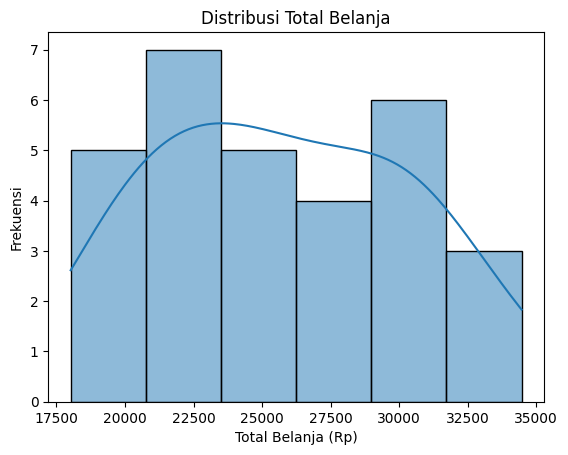

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribusi Total Belanja
sns.histplot(df['Total_Belanja'], kde=True)
plt.title("Distribusi Total Belanja")
plt.xlabel("Total Belanja (Rp)")
plt.ylabel("Frekuensi")
plt.show()

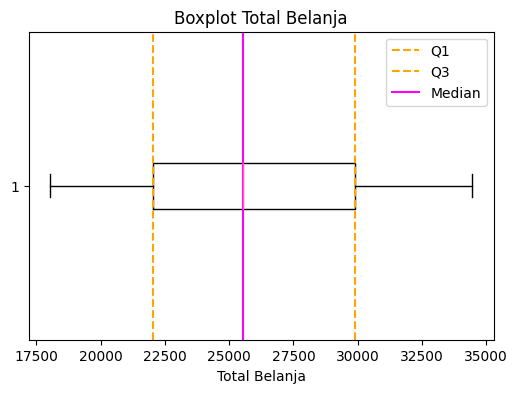

In [ ]:
# Visualisasi Boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df['Total_Belanja'], vert=False)

Q1 = df['Total_Belanja'].quantile(0.25)
Q3 = df['Total_Belanja'].quantile(0.75)
median = df['Total_Belanja'].median()

plt.axvline(Q1, linestyle='--',color="orange", label='Q1')
plt.axvline(Q3, linestyle='--',color="orange", label='Q3')
plt.axvline(median, linestyle='-',color="magenta", label='Median')

plt.legend()

plt.title('Boxplot Total Belanja')
plt.xlabel('Total Belanja')

plt.show()

#B. Expected Value

1. Tentukan variabel total belanja per orang.
2. Hitung expected value (rata-rata total belanja).
3. Pastikan perhitungan dilakukan dari data bersih.

In [ ]:
# Variabel Total Belanja Per Orang
# Menentukan Variabel Acak

df['Total_Belanja']

,Total_Belanja
0,25788
1,21836
2,27395
3,25056
4,25448
5,19552
6,30292
7,32807
8,18020
9,24300


In [ ]:
# Rentang Belanja
bins = [17500, 20000, 22500, 25000, 27500, 30000, 32500, 35000]

df['Rentang'] = pd.cut(df['Total_Belanja'], bins=bins)

# Membuat Frekuensi
freq = df['Rentang'].value_counts().sort_index()
print(freq)

Rentang
(17500, 20000]    4
(20000, 22500]    6
(22500, 25000]    3
(25000, 27500]    6
(27500, 30000]    4
(30000, 32500]    4
(32500, 35000]    3
Name: count, dtype: int64


In [ ]:
# Hitung Probabilitas
prob = freq / freq.sum()
print(prob)

Rentang
(17500, 20000]    0.133333
(20000, 22500]    0.200000
(22500, 25000]    0.100000
(25000, 27500]    0.200000
(27500, 30000]    0.133333
(30000, 32500]    0.133333
(32500, 35000]    0.100000
Name: count, dtype: float64


In [ ]:
EV = df["Total_Belanja"].mean()
print("Expected Value:", EV)

Expected Value: 25716.766666666666


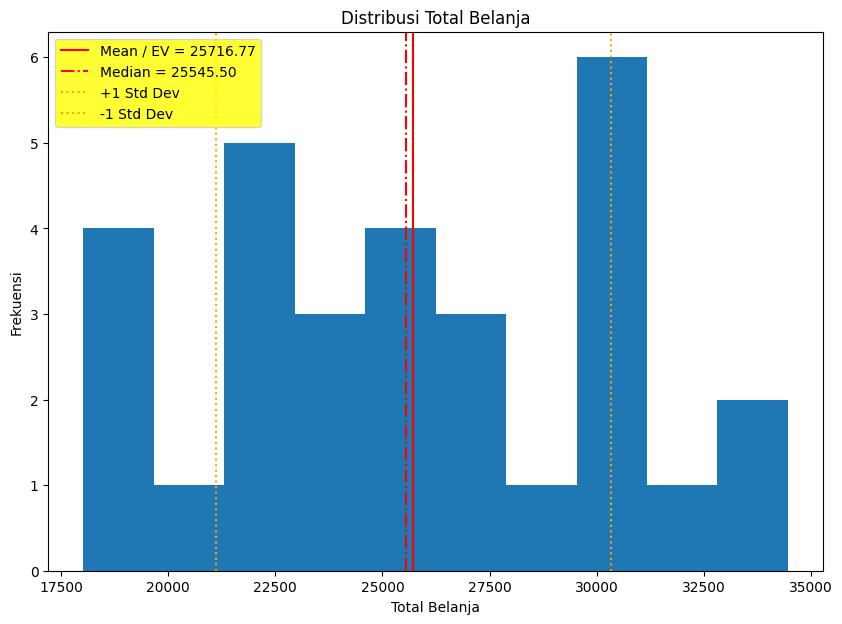

In [ ]:
# Hitung Statistik
mean_val = df["Total_Belanja"].mean()
median_val = df["Total_Belanja"].median()
std_val = df["Total_Belanja"].std()

# Buat Histogram
plt.figure(figsize=(10,7))
plt.hist(df["Total_Belanja"], bins=10)

# Garis Statistik Merah
plt.axvline(mean_val, linestyle="-", color="red", label=f"Mean / EV = {mean_val:.2f}")
plt.axvline(median_val, linestyle="-.", color="red", label=f"Median = {median_val:.2f}")
plt.axvline(mean_val + std_val, linestyle=":", color="orange", label="+1 Std Dev")
plt.axvline(mean_val - std_val, linestyle=":", color="orange", label="-1 Std Dev")

# Legend
legend = plt.legend(loc="upper left")
legend.get_frame().set_facecolor("yellow")

plt.title("Distribusi Total Belanja")
plt.xlabel("Total Belanja")
plt.ylabel("Frekuensi")

plt.show()

#C. Korelasi

1. Tentukan variabel:
- X: Usia
- Y: Total Belanja
2. Hitung nilai korelasi (Pearson correlation).

3. Buat visualisasi:
- Scatter plot usia vs total belanja

In [ ]:
# Menghitung Korelasi Pearson
corr = df['Usia'].corr(df['Total_Belanja'])
print(corr)


0.8897640659194177


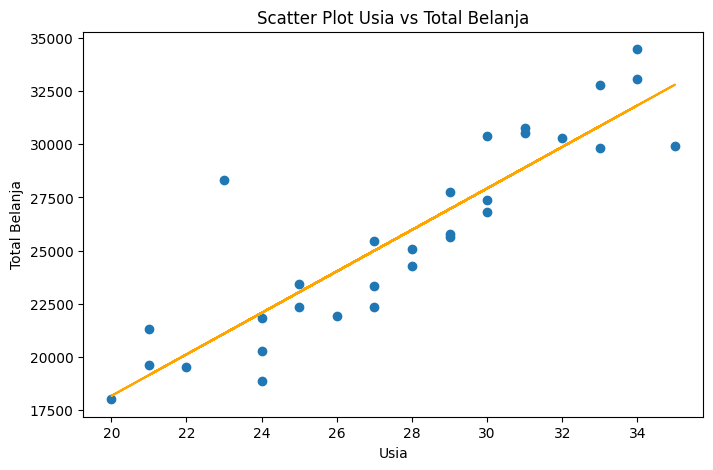

In [ ]:
# Visualisasi Scatter Plot
import matplotlib.pyplot as plt

# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(df['Usia'], df['Total_Belanja'])

# Membuat Garis Regresi
m, b = np.polyfit(df['Usia'], df['Total_Belanja'], 1)
plt.plot(df['Usia'], m*df['Usia'] + b, color="orange")

plt.title('Scatter Plot Usia vs Total Belanja')
plt.xlabel('Usia')
plt.ylabel('Total Belanja')

plt.show()

#D. Distribusi Data

1. Gunakan histogram atau kurva distribusi.
2. Amati: - Simetri data - Kemiringan (skewness)
3. Bandingkan mean dan median.

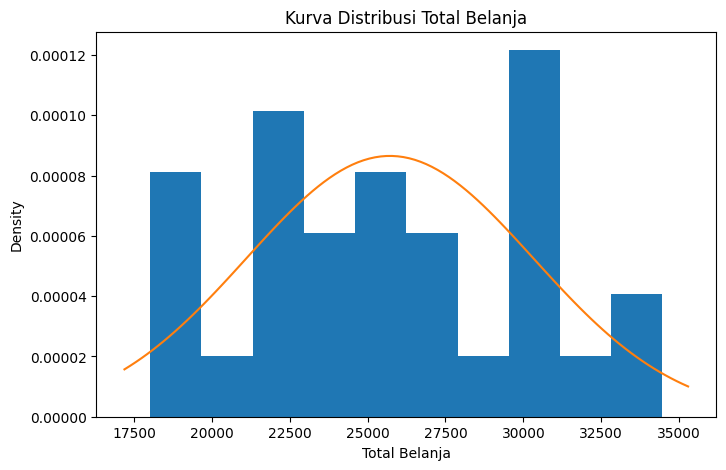

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

data = df["Total_Belanja"]

# Mean dan Std
mean_val = data.mean()
std_val = data.std()

# Plot Histogram
plt.figure(figsize=(8,5))
plt.hist(data, bins=10, density=True)

# Kurva
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean_val, std_val)

plt.plot(x, p)

plt.title("Kurva Distribusi Total Belanja")
plt.xlabel("Total Belanja")
plt.ylabel("Density")

plt.show()


In [ ]:
skewness = df["Total_Belanja"].skew()
print("Skewness:", skewness)

Skewness: 0.12712800723936465


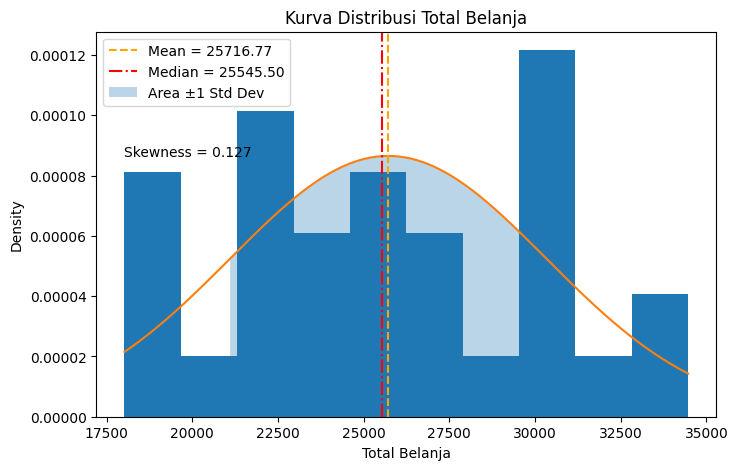

In [ ]:
# Hitung statistik
mean_val = data.mean()
std_val = data.std()
skew_val = data.skew()
median_val = data.median()

# Buat Kurva
x = np.linspace(data.min(), data.max(), 200)
pdf = norm.pdf(x, mean_val, std_val)

plt.figure(figsize=(8,5))

# Histogram Density
plt.hist(data, bins=10, density=True)

# Kurva
plt.plot(x, pdf)

# Garis mean
plt.axvline(mean_val, linestyle="--",color ="Orange", label=f"Mean = {mean_val:.2f}")

# Garis Median
plt.axvline(median_val, linestyle="-.",color ="Red", label=f"Median = {median_val:.2f}")

# Area ±1 Std Dev
x_fill = np.linspace(mean_val - std_val, mean_val + std_val, 200)
pdf_fill = norm.pdf(x_fill, mean_val, std_val)
plt.fill_between(x_fill, pdf_fill, alpha=0.3, label="Area ±1 Std Dev")

# Tampilkan skewness di grafik
plt.text(data.min(), max(pdf), f"Skewness = {skew_val:.3f}")

plt.title("Kurva Distribusi Total Belanja")
plt.xlabel("Total Belanja")
plt.ylabel("Density")
plt.legend()

plt.show()

#E. Z-Score

1. Hitung Z-Score untuk variabel total belanja.

2. Pilih minimal 2 sampel individu dengan nilai Z-Score berbeda.

3. Gunakan rumus Z-Score yang sesuai.

In [ ]:
import pandas as pd

mean_val = df["Total_Belanja"].mean()
std_val = df["Total_Belanja"].std()

# Z-Score semua data
df["Z_Score"] = (df["Total_Belanja"] - mean_val) / std_val

print(df[["Nama", "Total_Belanja", "Z_Score"]])


       Nama  Total_Belanja   Z_Score
0       Ayu          25788  0.015445
1      Bima          21836 -0.841426
2     Citra          27395  0.363874
3      Dion          25056 -0.143267
4       Eka          25448 -0.058274
5     Febri          19552 -1.336642
6      Gita          30292  0.992000
7      Hadi          32807  1.537301
8     Intan          18020 -1.668810
9      Joko          24300 -0.307183
10  Kartika          29837  0.893347
11   Luthfi          18875 -1.483429
12     Mega          19610 -1.324067
13    Nurul          30410  1.017585
14      Oki          21950 -0.816709
15  Purnama          28308  0.561830
16    Rizky          29900  0.907007
17     Sari          26810  0.237034
18    Teguh          30756  1.092605
19      Umi          21311 -0.955257
20     Vino          22370 -0.725645
21    Wayan          30508  1.038833
22     Yuni          34466  1.897005
23    Zahra          22350 -0.729981
24    Andre          25643 -0.015994
25     Dewi          20300 -1.174461
2

In [ ]:
# Hitung Mean Dan Standar Deviasi
mean_val = df["Total_Belanja"].mean()
std_val = df["Total_Belanja"].std()

print ("Mean:", mean_val)
print ("Standar Deviasi:", std_val)

# Z-Score
df["Z_Score"] = (df["Total_Belanja"] - mean_val) / std_val

# Sample
sample_2 = df[["Nama", "Total_Belanja", "Z_Score"]].iloc[[0, 5]]

print(sample_2)

Mean: 25716.766666666666
Standar Deviasi: 4612.12936597682
    Nama  Total_Belanja   Z_Score
0    Ayu          25788  0.015445
5  Febri          19552 -1.336642
